In [1]:
#---FLOW OF PRACTICAL 5

#1. Import libraries
#2. Load dataset
#3. Preprocess data
#4. Split train/test
#5. Feature scaling
#6. Train Logistic Regression model
#7. Predict values
#8. Create confusion matrix
#9. Calculate accuracy
#10. Plot graph

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")

In [4]:
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [5]:
# Dataset Information
print("\nShape of Dataset:")
print(df.shape)


Shape of Dataset:
(400, 5)


In [6]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')


In [7]:
print("\nData Types:")
print(df.dtypes)


Data Types:
User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [9]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


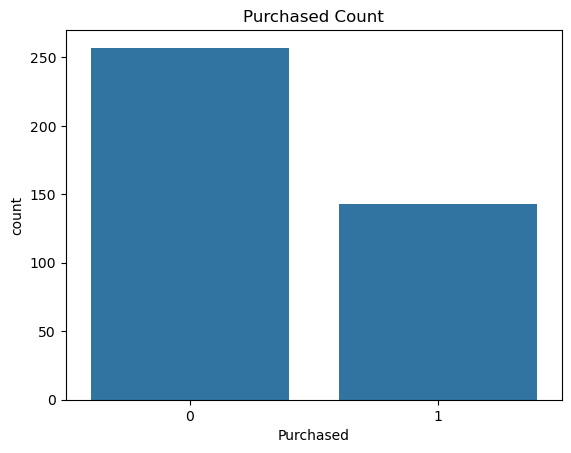

In [10]:
# Visualize Purchased Count
sns.countplot(x='Purchased', data=df)
plt.title("Purchased Count")
plt.show()

In [11]:
# Features and Target
X = df[['Age', 'EstimatedSalary']]

y = df['Purchased']

In [12]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [13]:
# Feature Scaling
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

In [14]:
# Create Logistic Regression Model
model = LogisticRegression()

In [15]:
# Train Model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
# Predict Test Values
y_pred = model.predict(X_test)

In [17]:
# Probability Prediction
y_prob = model.predict_proba(X_test)


In [18]:
print("\nPredicted Probabilities:")
print(y_prob[:5])


Predicted Probabilities:
[[0.88724662 0.11275338]
 [0.83320406 0.16679594]
 [0.80547266 0.19452734]
 [0.91055238 0.08944762]
 [0.90251404 0.09748596]]


In [19]:
# Actual vs Predicted
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})


In [20]:
print("\nActual vs Predicted:")
print(comparison.head(10))


Actual vs Predicted:
     Actual  Predicted
132       0          0
309       0          0
341       0          0
196       0          0
246       0          0
60        0          0
155       0          0
261       1          1
141       0          0
214       0          1


In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[65  3]
 [ 8 24]]


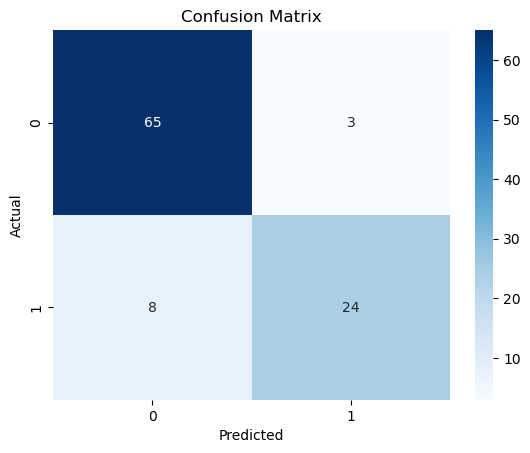

In [22]:
# Heatmap for Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.89


In [24]:
# Precision
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.8888888888888888


In [25]:
# Recall
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.75


In [26]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



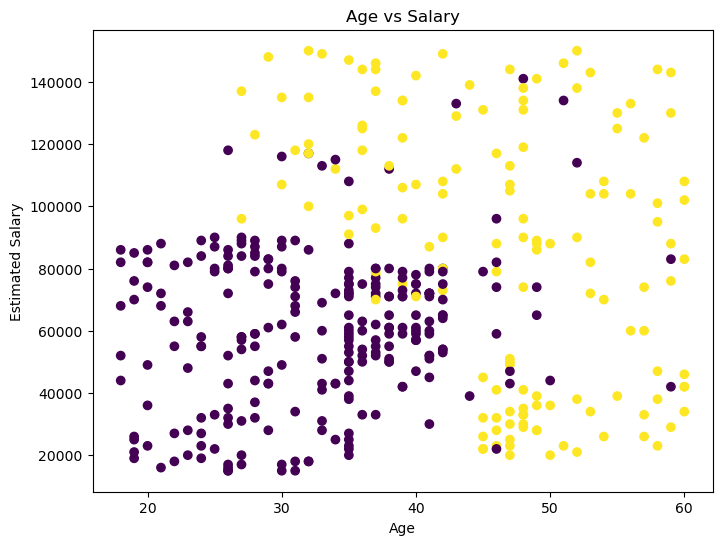

In [27]:
# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(df['Age'], df['EstimatedSalary'],
            c=df['Purchased'])

plt.xlabel("Age")
plt.ylabel("Estimated Salary")

plt.title("Age vs Salary")

plt.show()